In [1]:
%load_ext autoreload 
%autoreload 2

In [1]:
from ssa.utils import init_azure_model, init_openrouter_chat_model


In [3]:
from ssa.agents.policy import PolicyAgent


2025-09-11 12:43:08.912 | INFO     | ssa.market:__init__:118 - Set up LabourMarket with 10 agents and 16 jobs over 4 tasks. Initializing...
  0%|          | 0/15 [00:00<?, ?it/s]2025-09-11 12:43:08.936 | INFO     | ssa.agents.llm:get_agent_action:158 - === ROUND 1 ===

MARKET ACTIVITY:
This is Round 1. No history recorded yet.

RECENT ACTIONS:


>> REPUTATION - task_c: 2.5*, task_d: 2.6*, task_b: 2.3*, task_a: 2.2*

PREVIOUS REASONING
(First Turn - No reasoning trace yet)

LISTINGS:
task_a: task_a_0@7.0, task_a_1@8.0, task_a_2@9.0, task_a_3@10.0
task_b: task_b_0@7.0, task_b_1@8.0, task_b_2@9.0, task_b_3@10.0
task_c: task_c_0@7.0, task_c_1@8.0, task_c_2@9.0, task_c_3@10.0
task_d: task_d_0@7.0, task_d_1@8.0, task_d_2@9.0, task_d_3@10.0

2025-09-11 12:43:08.939 | INFO     | ssa.agents.llm:get_agent_action:158 - === ROUND 1 ===

MARKET ACTIVITY:
This is Round 1. No history recorded yet.

RECENT ACTIONS:


>> REPUTATION - task_c: 2.5*, task_d: 2.6*, task_b: 2.3*, task_a: 2.2*

PREVIOUS REAS

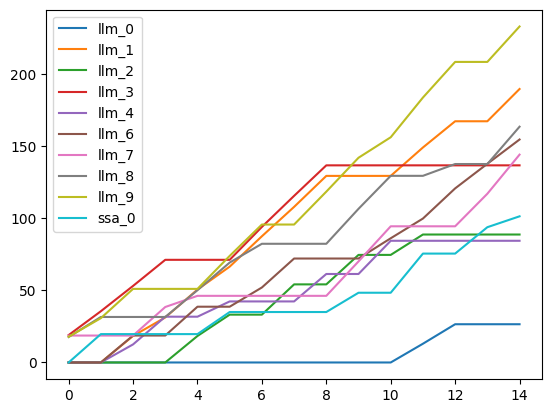

In [1]:
from ssa.galeshapley import multi_galeshapley
from ssa.market import LabourMarket, ExperimentLog, Job
from ssa.agents import StaticAgent, LLMAgent, OracleAgent, ImproveAgent
from ssa.agents.ssa import LLMSSA
from ssa.agents.policy import PolicyAgent
from ssa.tasks.cipher import CipherAgent, CipherTask
from ssa.tasks import ProxyAgent, ProxyTask
from ssa.utils import init_azure_model, init_openrouter_chat_model
from tqdm import trange
import numpy as np
import matplotlib.pyplot as plt

from ssa.market import LabourMarket, ExperimentLog, Job
from ssa.agents import StaticAgent, LLMAgent, OracleAgent, ImproveAgent
from ssa.agents.ssa import LLMSSA
from ssa.agents.policy import PolicyAgent
from ssa.tasks.cipher import CipherAgent, CipherTask
from ssa.tasks import ProxyAgent, ProxyTask
from ssa.utils import init_azure_model, init_openrouter_chat_model
from tqdm import trange
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(13123)
# model = init_azure_model()

task_ids = ["task_a", "task_b", "task_c", "task_d"]
tasks = [ProxyTask(t, noise=0.1) for t in task_ids]

jobs = [Job(id=f"{task_id}_{i}", task_id=task_id, base_reward=7 + i) for task_id in task_ids for i in range(4)]

# agents = [PolicyAgent(agent_id=f"pol_{i}", jobs=jobs, model=None, verbose=False) for i in range(4)]
# for agent in agents:
#     agent.set_policy(underbid_factor=0.9)

# agents[0].set_policy(task_preferences=['task_a', 'task_b', 'task_c', 'task_d'], train_p=0)
# # agents[1].set_policy(task_preferences=['task_c', 'task_b', 'task_a', 'task_d'])
# # agents[2].set_policy(task_preferences=['task_b', 'task_c', 'task_a', 'task_d'])
# agents[3].set_policy(task_preferences=['task_b', 'task_c', 'task_a', 'task_d'], train_t=10)

agents = []
# model = init_openrouter_chat_model(model_name='openai/gpt-oss-120b', temperature=0.5)
model = None
agents.append(LLMAgent(agent_id=f"llm_0", jobs=jobs, model=model, verbose=False))
agents.append(LLMAgent(agent_id=f"llm_1", jobs=jobs, model=model, verbose=False))
agents.append(LLMAgent(agent_id=f"llm_2", jobs=jobs, model=model, verbose=False))
agents.append(LLMAgent(agent_id=f"llm_3", jobs=jobs, model=model, verbose=False))
agents.append(LLMAgent(agent_id=f"llm_4", jobs=jobs, model=model, verbose=False))
agents.append(LLMAgent(agent_id=f"llm_6", jobs=jobs, model=model, verbose=False))
agents.append(LLMAgent(agent_id=f"llm_7", jobs=jobs, model=model, verbose=False))
agents.append(LLMAgent(agent_id=f"llm_8", jobs=jobs, model=model, verbose=False))
agents.append(LLMAgent(agent_id=f"llm_9", jobs=jobs, model=model, verbose=False))
agents.append(LLMSSA(agent_id=f"ssa_0", jobs=jobs, model=model, verbose=True))

market = LabourMarket(jobs=jobs, agent_pref_limit=5, market_limit=3, tasks=tasks, agents=agents, skill_phi=0.9, rep_window=5, rep_lambda=0.5, rep_sensitivity=2, gumbel_t=0.0)
for _ in trange(15):
    market.simulate_timestep()

hx = market.get_job_performance(task_id='task_a', filter_initial=True)

exp_log = market.export()

rew = np.cumsum(exp_log.agent_reward_history, axis=1)
plt.plot(rew.T, label=exp_log.agent_ids)
plt.legend()


In [3]:
exp_log.agent_reward_history.shape

(10, 15)

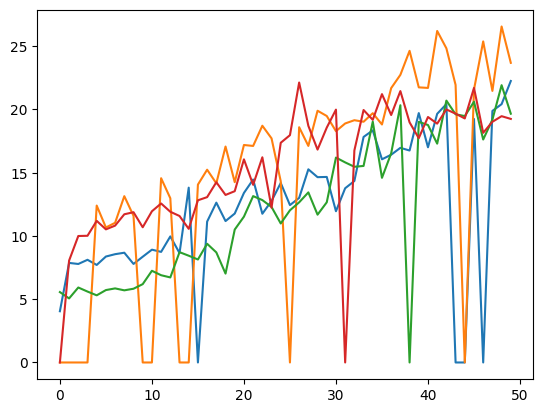

In [6]:
el = ExperimentLog.load('logs/ssa_test_1.log')

plt.plot(el.agent_reward_history.T)

In [8]:

# np.random.seed(13123)
# model = init_azure_model()

task_ids = [f"task_{i}" for i in range(5)]
tasks = [ProxyTask(t, noise=0.1) for t in task_ids]

jobs = [Job(id=f"{task_id}_{i}", task_id=task_id, job_p=0.9, base_reward=7 + i) for task_id in task_ids for i in range(2)]

agents = [PolicyAgent(agent_id=f"pol_{i}", jobs=jobs, model=None, verbose=False) for i in range(5)]
for agent in agents:
    agent.set_policy(train_p=0.2, underbid_factor=0.9)
agents[0].set_policy(job_preferences=['task_0_0', 'task_0_1'])
agents[1].set_policy(greedy=True)

# agents[0].set_policy(task_preferences=['task_a', 'task_b', 'task_c', 'task_d'], train_p=0)
# agents[1].set_policy(task_preferences=['task_c', 'task_b', 'task_a', 'task_d'])
# agents[2].set_policy(task_preferences=['task_b', 'task_c', 'task_a', 'task_d'])
# agents[3].set_policy(task_preferences=['task_b', 'task_c', 'task_a', 'task_d'], train_t=10)

market = LabourMarket(jobs=jobs, market_limit=1, tasks=tasks, agents=agents, skill_phi=0.1, rep_window=50, rep_lambda=0.5, rep_sensitivity=2, gumbel_t=0.0)
for _ in trange(50):
    market.simulate_timestep()

hx = market.get_job_performance(task_id='task_a', filter_initial=True)

exp_log = market.export()

# rew = np.cumsum(exp_log.agent_reward_history, axis=1)
# plt.plot(rew.T, label=exp_log.agent_ids)
# plt.legend()


2025-09-11 12:44:07.769 | INFO     | ssa.market:__init__:118 - Set up LabourMarket with 5 agents and 10 jobs over 5 tasks. Initializing...
100%|██████████| 50/50 [00:00<00:00, 428.64it/s]


In [9]:
exp_log.agent_bids['task_1_0']

[[],
 [(1, 6.3),
  (2, 6.3),
  (3, 6.3),
  (4, 6.3),
  (6, 6.3),
  (7, 6.3),
  (8, 6.3),
  (9, 6.3),
  (10, 6.3),
  (13, 6.3),
  (14, 6.3),
  (15, 6.3),
  (16, 6.3),
  (17, 6.3),
  (18, 6.3),
  (19, 6.3),
  (20, 6.3),
  (21, 6.3),
  (23, 6.3),
  (24, 6.3),
  (25, 6.3),
  (26, 6.3),
  (28, 6.3),
  (29, 6.3),
  (30, 6.3),
  (31, 6.3),
  (32, 6.3),
  (33, 6.3),
  (34, 6.3),
  (35, 6.3),
  (36, 6.3),
  (37, 6.3),
  (38, 6.3),
  (40, 6.3),
  (41, 6.3),
  (43, 6.3),
  (44, 6.3),
  (45, 6.3),
  (46, 6.3),
  (47, 6.3),
  (49, 6.3)],
 [(1, 6.3),
  (3, 6.3),
  (4, 6.3),
  (5, 6.3),
  (6, 6.3),
  (7, 6.3),
  (8, 6.3),
  (9, 6.3),
  (10, 6.3),
  (11, 6.3),
  (12, 6.3),
  (13, 6.3),
  (14, 6.3),
  (15, 6.3),
  (16, 6.3),
  (17, 6.3),
  (18, 6.3),
  (19, 6.3),
  (20, 6.3),
  (22, 6.3),
  (23, 6.3),
  (24, 6.3),
  (25, 6.3),
  (26, 6.3),
  (28, 6.3),
  (30, 6.3),
  (31, 6.3),
  (32, 6.3),
  (33, 6.3),
  (34, 6.3),
  (35, 6.3),
  (38, 6.3),
  (39, 6.3),
  (40, 6.3),
  (41, 6.3),
  (42, 6.3),
  (43, 6.

In [21]:
unemployed = []

2025-09-08 23:44:35.399 | INFO     | ssa.market:__init__:118 - Set up LabourMarket with 100 agents and 100 jobs over 10 tasks. Initializing...
100%|██████████| 100/100 [00:22<00:00,  4.46it/s]
2025-09-08 23:45:10.504 | INFO     | ssa.market:__init__:118 - Set up LabourMarket with 100 agents and 100 jobs over 10 tasks. Initializing...
100%|██████████| 100/100 [00:22<00:00,  4.46it/s]
2025-09-08 23:45:44.679 | INFO     | ssa.market:__init__:118 - Set up LabourMarket with 100 agents and 100 jobs over 10 tasks. Initializing...
100%|██████████| 100/100 [00:22<00:00,  4.51it/s]
2025-09-08 23:46:19.788 | INFO     | ssa.market:__init__:118 - Set up LabourMarket with 100 agents and 100 jobs over 10 tasks. Initializing...
100%|██████████| 100/100 [00:21<00:00,  4.74it/s]
2025-09-08 23:46:52.752 | INFO     | ssa.market:__init__:118 - Set up LabourMarket with 100 agents and 100 jobs over 10 tasks. Initializing...
100%|██████████| 100/100 [00:21<00:00,  4.66it/s]
2025-09-08 23:47:26.386 | INFO     

Text(0.5, 0, 'unemployment')

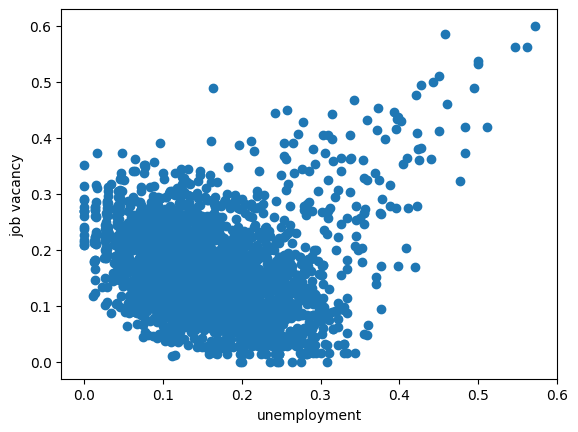

In [22]:
from tqdm import tqdm

n_tasks = 10
n_jobs = 10
n_agents = 100
market_limit = 1
market_pref_limit = 40
agent_pref_limit = 10
job_p = 0.7
train_p = 0.3
n_steps = 100
# for market_pref_limit in [5, 10]:
#     for agent_pref_limit in [3, 5]:

for job_p in [0.7, 0.75, 0.8, 0.85, 0.9]:
    for train_p in [0.1, 0.15, 0.2, 0.25, 0.3]:
        # pass

        task_ids = [f"task_{i}" for i in range(n_tasks)]
        tasks = [ProxyTask(t, noise=0.1) for t in task_ids]

        jobs = [Job(id=f"{task_id}_{i}", task_id=task_id, job_p=job_p, base_reward=10) for task_id in task_ids for i in range(n_jobs)]

        agents = [PolicyAgent(agent_id=f"pol_{i}", jobs=jobs, model=None, verbose=False) for i in range(n_agents)]

        for agent in agents:
            agent.set_policy(train_p=train_p)
        for agent in agents[:70]:
            task_preferences = [agent.task_ids[i] for i in np.random.permutation(agent.n_tasks)]
            agent.set_policy(task_preferences=task_preferences, train_p=train_p, underbid_factor=0.9)

        market = LabourMarket(jobs=jobs, market_pref_limit=market_pref_limit, agent_pref_limit=agent_pref_limit, market_limit=market_limit, tasks=tasks, agents=agents, skill_phi=0.1, rep_window=50, rep_lambda=0.5, rep_sensitivity=2, gumbel_t=0.0)
        for _ in trange(n_steps):
            market.simulate_timestep()

        exp_log = market.export()

        for hx in exp_log.history:
            unemployed.append(((len(hx.unmatched_agents) - np.sum([a.action == 'train' for a in hx.agent_actions])) / (n_agents - np.sum([a.action == 'train' for a in hx.agent_actions])), len(hx.unmatched_jobs) / len(hx.base_prices)))

u = np.array(unemployed)
plt.scatter(u[:, 0], u[:, 1])
plt.ylabel('job vacancy')
plt.xlabel('unemployment')

2025-09-10 12:01:16.567 | INFO     | ssa.market:__init__:118 - Set up LabourMarket with 10 agents and 16 jobs over 4 tasks. Initializing...
100%|██████████| 100/100 [00:00<00:00, 230.08it/s]


Text(0.5, 0, 'unemployment')

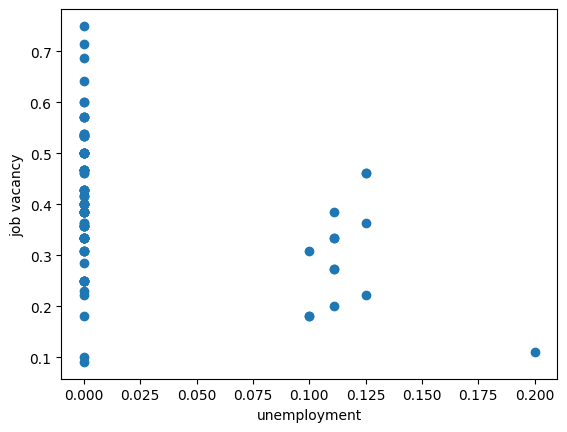

In [ ]:
_unemployed = []
from tqdm import tqdm

n_tasks = 4
n_jobs = 4
n_agents = 10
market_limit = 1
market_pref_limit = 10
agent_pref_limit = 5
job_p = 0.8
train_p = 0.2
n_steps = 100
# for market_pref_limit in [5, 10]:
#     for agent_pref_limit in [3, 5]:

task_ids = [f"task_{i}" for i in range(n_tasks)]
tasks = [ProxyTask(t, noise=0.1) for t in task_ids]

jobs = [Job(id=f"{task_id}_{i}", task_id=task_id, job_p=job_p, base_reward=10) for task_id in task_ids for i in range(n_jobs)]

agents = [PolicyAgent(agent_id=f"pol_{i}", jobs=jobs, model=None, verbose=False) for i in range(n_agents)]

for agent in agents:
    agent.set_policy(train_p=train_p)
for agent in agents[:70]:
    task_preferences = [agent.task_ids[i] for i in np.random.permutation(agent.n_tasks)]
    agent.set_policy(task_preferences=task_preferences, train_p=train_p, underbid_factor=0.9)

market = LabourMarket(jobs=jobs, market_pref_limit=market_pref_limit, agent_pref_limit=agent_pref_limit, market_limit=market_limit, tasks=tasks, agents=agents, skill_phi=0.1, rep_window=20, rep_lambda=0.5, rep_sensitivity=2, gumbel_t=0.0)
for _ in trange(n_steps):
    market.simulate_timestep()

exp_log = market.export()

for hx in exp_log.history:
    _unemployed.append(((len(hx.unmatched_agents) - np.sum([a.action == 'train' for a in hx.agent_actions])) / (n_agents - np.sum([a.action == 'train' for a in hx.agent_actions])), len(hx.unmatched_jobs) / len(hx.base_prices)))

u = np.array(_unemployed)
plt.scatter(u[:, 0], u[:, 1])
plt.ylabel('job vacancy')
plt.xlabel('unemployment')

Fitted parameters [a, b, c]: [ 0.0395626   0.11567441 -0.00052701]
R²: 0.4190
RMSE: 0.0423
Outliers removed: 50


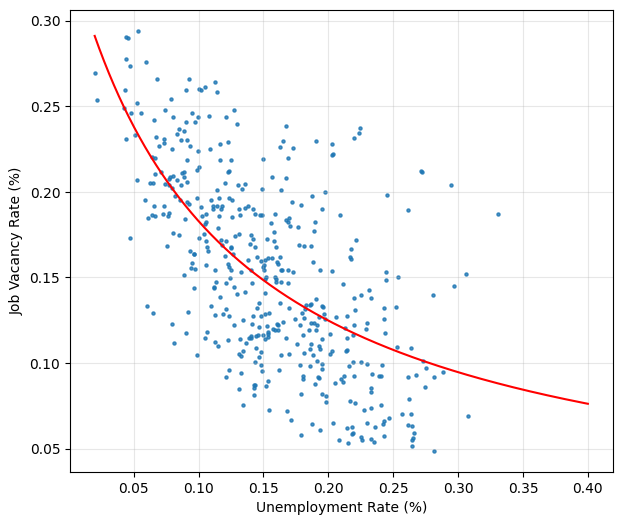

In [142]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import zscore
import matplotlib.pyplot as plt

def hyperbolic_func(x, a, b, c):
    """Hyperbolic function: y = a/(x + b) + c"""
    return a / (x + b) + c

def remove_outliers_residual_based(X, y, func, params, outlier_percent=5):
    """Remove outliers based on residuals from initial fit"""
    y_pred = func(X, *params)
    residuals = np.abs(y - y_pred)
    threshold = np.percentile(residuals, 100 - outlier_percent)
    mask = residuals <= threshold
    return X[mask], y[mask], mask

def remove_outliers_zscore(X, y, z_threshold=2.5):
    """Remove outliers based on Z-score"""
    z_scores_x = np.abs(zscore(X))
    z_scores_y = np.abs(zscore(y))
    mask = (z_scores_x < z_threshold) & (z_scores_y < z_threshold)
    return X[mask], y[mask], mask

def fit_hyperbola_with_outlier_removal(data, outlier_percent=5, method='residual'):
    """
    Fit hyperbolic curve with outlier removal
    
    Parameters:
    - data: numpy array of shape (n, 2) or tuple (X, y)
    - outlier_percent: percentage of outliers to remove
    - method: 'residual' or 'zscore'
    """
    
    # Handle input format
    if isinstance(data, tuple):
        X, y = data
    else:
        X, y = data[:, 0], data[:, 1]
    
    # Initial fit to identify outliers (if using residual method)
    if method == 'residual':
        # Robust initial parameter estimation
        try:
            initial_params = [np.std(y) * np.mean(X), np.mean(X), np.mean(y)]
            popt_initial, _ = curve_fit(hyperbolic_func, X, y, p0=initial_params, maxfev=5000)
        except:
            # Fallback parameters
            popt_initial = [1.0, 1.0, np.mean(y)]
        
        X_clean, y_clean, mask = remove_outliers_residual_based(
            X, y, hyperbolic_func, popt_initial, outlier_percent
        )
    else:  # zscore method
        z_threshold = np.sqrt(2 * np.log(100/outlier_percent))  # Convert percentage to z-score
        X_clean, y_clean, mask = remove_outliers_zscore(X, y, z_threshold)
    
    # Final fit on cleaned data
    try:
        initial_params = [np.std(y_clean) * np.mean(X_clean), np.mean(X_clean), np.mean(y_clean)]
        popt_final, pcov = curve_fit(hyperbolic_func, X_clean, y_clean, p0=initial_params, maxfev=5000)
    except Exception as e:
        raise RuntimeError(f"Curve fitting failed: {e}")
    
    # Calculate fit quality metrics
    y_pred = hyperbolic_func(X_clean, *popt_final)
    r_squared = 1 - np.sum((y_clean - y_pred)**2) / np.sum((y_clean - np.mean(y_clean))**2)
    rmse = np.sqrt(np.mean((y_clean - y_pred)**2))
    
    results = {
        'params': popt_final,
        'covariance': pcov,
        'X_clean': X_clean,
        'y_clean': y_clean,
        'outlier_mask': mask,
        'r_squared': r_squared,
        'rmse': rmse,
        'outliers_removed': len(X) - len(X_clean)
    }
    
    return results

# Fit with outlier removal
results = fit_hyperbola_with_outlier_removal(
    u, 
    outlier_percent=10, 
    method='residual'
)

print(f"Fitted parameters [a, b, c]: {results['params']}")
print(f"R²: {results['r_squared']:.4f}")
print(f"RMSE: {results['rmse']:.4f}")
print(f"Outliers removed: {results['outliers_removed']}")

# Plot results
X = u[:,0]
y = u[:,1]
plt.figure(figsize=(7, 6))
# plt.scatter(X, y, alpha=0.6, label='Original data')
plt.scatter(results['X_clean'], results['y_clean'], color='tab:blue', alpha=0.8, s=5, label='data')

X_plot = np.linspace(np.min(X), 0.4, 1000)
y_plot = hyperbolic_func(X_plot, *results['params'])
plt.plot(X_plot, y_plot, 'r-', label=f'Fitted curve: y = {results["params"][0]:.2f}/(x + {results["params"][1]:.2f}) + {results["params"][2]:.2f}')

plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Job Vacancy Rate (%)')
# plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [107]:
unemployed

[(np.float64(0.4222222222222222), 0.2777777777777778),
 (np.float64(0.37777777777777777), 0.2911392405063291),
 (np.float64(0.35555555555555557), 0.24675324675324675),
 (np.float64(0.41935483870967744), 0.16923076923076924),
 (np.float64(0.29411764705882354), 0.2),
 (np.float64(0.3023255813953488), 0.15492957746478872),
 (np.float64(0.3333333333333333), 0.08823529411764706),
 (np.float64(0.29347826086956524), 0.04411764705882353),
 (np.float64(0.2872340425531915), 0.0821917808219178),
 (np.float64(0.22727272727272727), 0.10526315789473684),
 (np.float64(0.26373626373626374), 0.04285714285714286),
 (np.float64(0.32967032967032966), 0.031746031746031744),
 (np.float64(0.2696629213483146), 0.09722222222222222),
 (np.float64(0.25842696629213485), 0.043478260869565216),
 (np.float64(0.28421052631578947), 0.02857142857142857),
 (np.float64(0.2608695652173913), 0.05555555555555555),
 (np.float64(0.26881720430107525), 0.02857142857142857),
 (np.float64(0.2857142857142857), 0.07142857142857142)

In [126]:
u = np.array(unemployed)


In [137]:
u = np.array(unemployed).reshape(500, 5, 2).mean(axis=1)

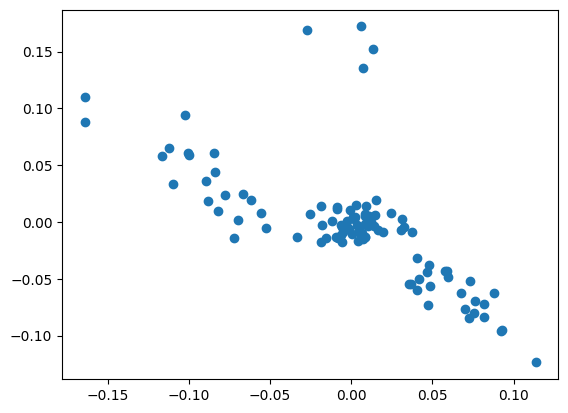

In [124]:
u = np.array(unemployed)
u[:, 1] = 1 - u[:, 1]
u2 = u.reshape(100, 25, 2).mean(axis=1)
u2_diff = np.diff(u2, axis=0)

unemployed_rate = u2_diff[:, 0]
gdp = u2_diff[:, 1]
plt.scatter(gdp, unemployed_rate)


In [94]:
u = np.array(unemployed)
u[:, 1] = 1 - u[:, 1]
u_diff = np.diff(u, axis=0)

In [121]:
import numpy as np
from scipy import stats
from scipy.stats import zscore
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

def remove_outliers_residual_based(X, y, slope, intercept, outlier_percent=5):
    """Remove outliers based on residuals from initial linear fit"""
    y_pred = slope * X + intercept
    residuals = np.abs(y - y_pred)
    threshold = np.percentile(residuals, 100 - outlier_percent)
    mask = residuals <= threshold
    return X[mask], y[mask], mask

def remove_outliers_zscore(X, y, z_threshold=2.5):
    """Remove outliers based on Z-score"""
    z_scores_x = np.abs(zscore(X))
    z_scores_y = np.abs(zscore(y))
    mask = (z_scores_x < z_threshold) & (z_scores_y < z_threshold)
    return X[mask], y[mask], mask

def remove_outliers_cook_distance(X, y, threshold=4):
    """Remove outliers based on Cook's distance"""
    from sklearn.linear_model import LinearRegression
    
    X_reshaped = X.reshape(-1, 1) if X.ndim == 1 else X
    model = LinearRegression().fit(X_reshaped, y)
    y_pred = model.predict(X_reshaped)
    
    # Calculate leverage (hat values)
    H = X_reshaped @ np.linalg.inv(X_reshaped.T @ X_reshaped) @ X_reshaped.T
    h = np.diag(H)
    
    # Calculate Cook's distance
    residuals = y - y_pred
    mse = np.mean(residuals**2)
    p = X_reshaped.shape[1] + 1  # number of parameters
    n = len(y)
    
    cook_d = (residuals**2 / (p * mse)) * (h / (1 - h)**2)
    
    # Remove points with Cook's distance > threshold/n
    mask = cook_d <= threshold / n
    return X[mask], y[mask], mask

def linear_regression_with_outlier_removal(data, outlier_percent=5, method='residual', robust_method=None):
    """
    Perform linear regression with outlier removal
    
    Parameters:
    - data: numpy array of shape (n, 2) or tuple (X, y)
    - outlier_percent: percentage of outliers to remove
    - method: 'residual', 'zscore', or 'cook'
    - robust_method: None, 'huber', or 'theil_sen' for robust regression
    """
    
    # Handle input format
    if isinstance(data, tuple):
        X, y = data
    else:
        X, y = data[:, 0], data[:, 1]
    
    X = np.asarray(X)
    y = np.asarray(y)
    
    # Initial fit for outlier detection
    if method == 'residual':
        slope_init, intercept_init, r_init, p_value_init, std_err_init = stats.linregress(X, y)
        X_clean, y_clean, mask = remove_outliers_residual_based(
            X, y, slope_init, intercept_init, outlier_percent
        )
    elif method == 'zscore':
        z_threshold = np.sqrt(2 * np.log(100/outlier_percent))
        X_clean, y_clean, mask = remove_outliers_zscore(X, y, z_threshold)
    elif method == 'cook':
        X_clean, y_clean, mask = remove_outliers_cook_distance(X, y)
    else:
        raise ValueError("Method must be 'residual', 'zscore', or 'cook'")
    
    # Final regression on cleaned data
    if robust_method == 'huber':
        # Huber regression (robust to outliers)
        X_reshaped = X_clean.reshape(-1, 1)
        huber = HuberRegressor(epsilon=1.35, max_iter=100)
        huber.fit(X_reshaped, y_clean)
        slope = huber.coef_[0]
        intercept = huber.intercept_
        
        # Calculate stats manually for robust regression
        y_pred = slope * X_clean + intercept
        r_value = np.corrcoef(y_clean, y_pred)[0, 1]
        r_squared = r2_score(y_clean, y_pred)
        
        # Standard error approximation for robust regression
        residuals = y_clean - y_pred
        mse = np.mean(residuals**2)
        x_var = np.var(X_clean)
        slope_std_err = np.sqrt(mse / (len(X_clean) * x_var))
        intercept_std_err = np.sqrt(mse * (1/len(X_clean) + np.mean(X_clean)**2/(len(X_clean) * x_var)))
        
        # P-value approximation (less reliable for robust regression)
        t_stat_slope = slope / slope_std_err
        p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat_slope), len(X_clean) - 2))
        
    elif robust_method == 'theil_sen':
        # Theil-Sen estimator
        slope, intercept, low_slope, high_slope = stats.theilslopes(y_clean, X_clean)
        y_pred = slope * X_clean + intercept
        r_value = np.corrcoef(y_clean, y_pred)[0, 1]
        r_squared = r2_score(y_clean, y_pred)
        
        # Standard errors not directly available for Theil-Sen
        slope_std_err = (high_slope - low_slope) / (2 * 1.96)  # Approximation
        intercept_std_err = np.nan  # Not easily computed
        p_value = np.nan  # Not easily computed
        
    else:
        # Standard least squares regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(X_clean, y_clean)
        slope_std_err = std_err
        
        # Calculate intercept standard error
        x_mean = np.mean(X_clean)
        x_var = np.var(X_clean)
        intercept_std_err = std_err * np.sqrt((1/len(X_clean)) + (x_mean**2)/(len(X_clean) * x_var))
    
    # Additional metrics
    y_pred_clean = slope * X_clean + intercept
    rmse = np.sqrt(np.mean((y_clean - y_pred_clean)**2))
    mae = np.mean(np.abs(y_clean - y_pred_clean))
    
    # Confidence intervals (95%)
    t_critical = stats.t.ppf(0.975, len(X_clean) - 2)
    slope_ci = [slope - t_critical * slope_std_err, slope + t_critical * slope_std_err]
    intercept_ci = [intercept - t_critical * intercept_std_err, intercept + t_critical * intercept_std_err]
    
    results = {
        'slope': slope,
        'intercept': intercept,
        'r_value': r_value,  # Correlation coefficient
        'r_squared': r_value**2 if not robust_method else r_squared,  # Coefficient of determination
        'p_value': p_value,
        'slope_std_err': slope_std_err,
        'intercept_std_err': intercept_std_err,
        'slope_ci': slope_ci,
        'intercept_ci': intercept_ci,
        'rmse': rmse,
        'mae': mae,
        'X_clean': X_clean,
        'y_clean': y_clean,
        'outlier_mask': mask,
        'outliers_removed': len(X) - len(X_clean),
        'n_samples': len(X_clean)
    }
    
    return results

def plot_regression_results(X_orig, y_orig, results, title="Linear Regression with Outlier Removal"):
    """Plot the regression results"""
    plt.figure(figsize=(12, 8))
    
    # # Original data
    # outlier_mask = ~results['outlier_mask']
    # if np.any(outlier_mask):
    #     plt.scatter(X_orig[outlier_mask], y_orig[outlier_mask], 
    #                color='red', alpha=0.6, s=50, label='Outliers (removed)', marker='x')
    
    # Clean data
    plt.scatter(results['X_clean'], results['y_clean'], 
               color='blue', alpha=0.7, s=30)
    
    # Regression line
    X_line = np.linspace(np.min(X_orig), np.max(X_orig), 100)
    y_line = results['slope'] * X_line + results['intercept']
    plt.plot(X_line, y_line, 'r-', linewidth=2, 
             label=f'y = {results["slope"]:.3f}x + {results["intercept"]:.3f}')
    
    # Confidence interval for the line
    y_pred_clean = results['slope'] * results['X_clean'] + results['intercept']
    residuals = results['y_clean'] - y_pred_clean
    mse = np.mean(residuals**2)
    x_mean = np.mean(results['X_clean'])
    x_var = np.var(results['X_clean'])
    
    # Standard error of prediction
    se_line = np.sqrt(mse * (1/len(results['X_clean']) + 
                             (X_line - x_mean)**2/(len(results['X_clean']) * x_var)))
    t_critical = stats.t.ppf(0.975, len(results['X_clean']) - 2)
    y_ci_lower = y_line - t_critical * se_line
    y_ci_upper = y_line + t_critical * se_line
    
    plt.fill_between(X_line, y_ci_lower, y_ci_upper, alpha=0.2, color='red', 
                     label='95% Confidence Interval')
    
    plt.xlabel('Change in unemployment rate')
    plt.ylabel('Change in GDP Growth')
    plt.title("")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Add statistics text box
    stats_text = f'R = {results["r_value"]:.4f}\n'
    stats_text += f'R² = {results["r_squared"]:.4f}\n'
    stats_text += f'RMSE = {results["rmse"]:.4f}\n'
    stats_text += f'p-value = {results["p_value"]:.2e}\n' if not np.isnan(results["p_value"]) else 'p-value = N/A\n'
    stats_text += f'n = {results["n_samples"]}\n'
    # stats_text += f'Outliers removed = {results["outliers_removed"]}'
    
    plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()



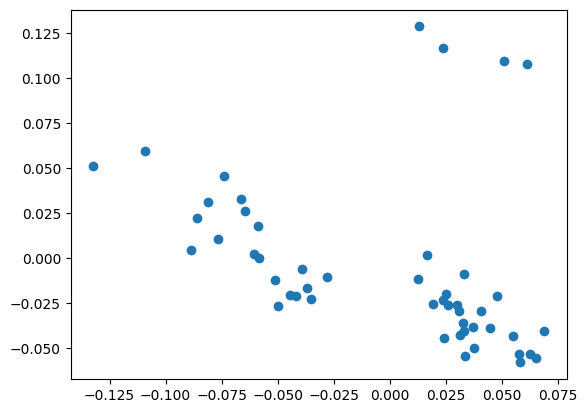

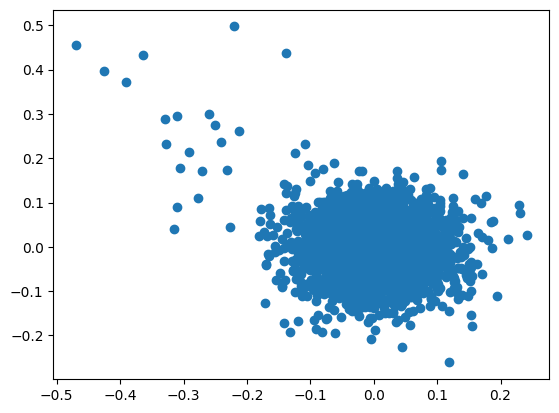

In [106]:
unemployed_rate = u_diff[:, 0]
gdp = u_diff[:, 1]
plt.scatter(gdp, unemployed_rate)


In [105]:
unemployed_rate

array([-0.04444444, -0.02222222,  0.06379928, ..., -0.01136364,
       -0.01581028,  0.0994313 ], shape=(2499,))


=== Method: residual + huber ===
Slope: -0.6472 ± 0.0529
Intercept: -0.0092 ± 0.0030
R-value: 0.7730
R²: 0.5952
RMSE: 0.0295
p-value: 0.00e+00
Outliers removed: 2


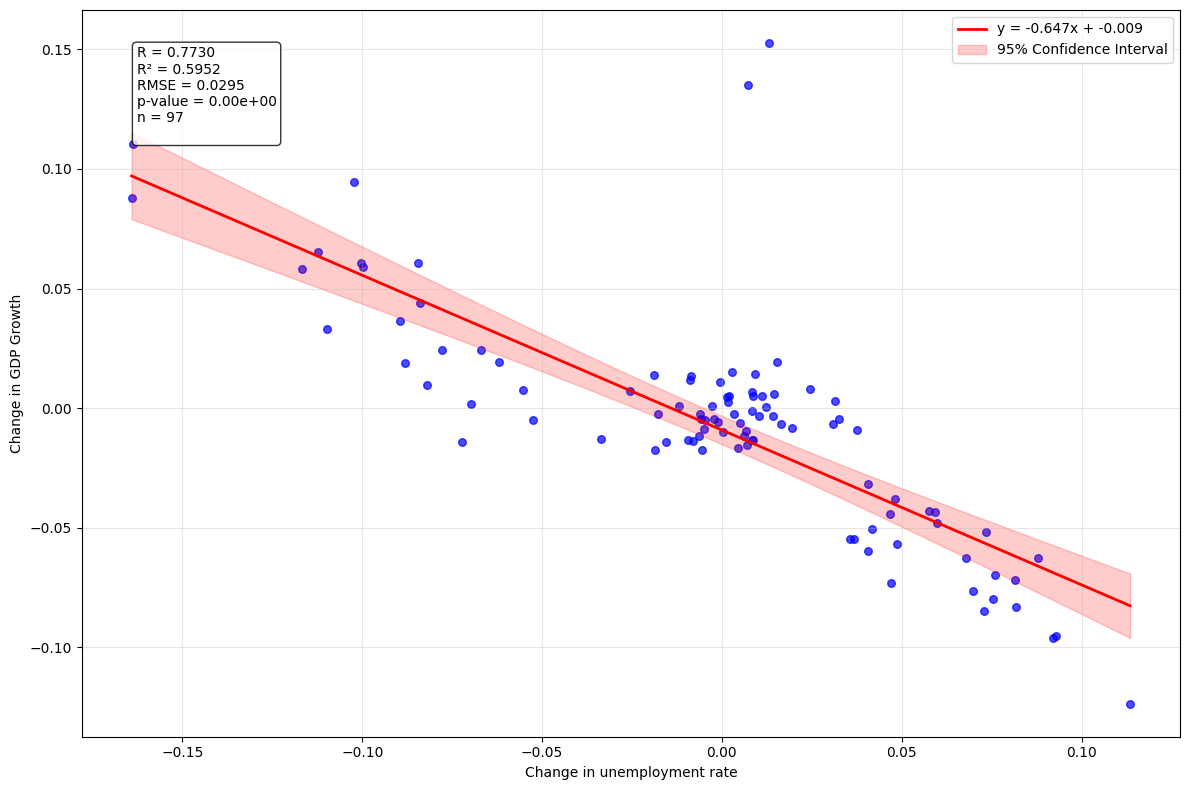

In [122]:

# Generate sample data with outliers
np.random.seed(42)

X_true = gdp
y_true = unemployed_rate

# Different methods comparison
methods = ['residual', 'zscore', 'cook']
robust_methods = [None, 'huber']

method = 'residual'
robust = 'huber'
method_name = f"{method}" + (f" + {robust}" if robust else "")
print(f"\n=== Method: {method_name} ===")

results = linear_regression_with_outlier_removal(
    (X_true, y_true), 
    outlier_percent=0.5, 
    method='zscore',
    robust_method=robust
)

print(f"Slope: {results['slope']:.4f} ± {results['slope_std_err']:.4f}")
print(f"Intercept: {results['intercept']:.4f} ± {results['intercept_std_err']:.4f}")
print(f"R-value: {results['r_value']:.4f}")
print(f"R²: {results['r_squared']:.4f}")
print(f"RMSE: {results['rmse']:.4f}")
print(f"p-value: {results['p_value']:.2e}" if not np.isnan(results['p_value']) else "p-value: N/A")
print(f"Outliers removed: {results['outliers_removed']}")

plot_regression_results(X_true, y_true, results, f"Linear Regression - {method_name}")


In [178]:
def gini(wealth):
    wealth = np.sort(wealth[wealth >= 0])
    n = len(wealth)
    cumsum = np.cumsum(wealth)
    return 1 - (2 * np.sum(cumsum)) / (n * cumsum[-1]) + 1/n

all_g = []

for market_limit in trange(10):

    task_ids = [f"task_{i}" for i in range(10)]
    tasks = [ProxyTask(t, noise=0.1) for t in task_ids]

    jobs = [Job(id=f"{task_id}_{i}", task_id=task_id, job_p=0.9, base_reward=7 + i) for task_id in task_ids for i in range(5)]

    agents = [PolicyAgent(agent_id=f"pol_{i}", jobs=jobs, model=None, verbose=False) for i in range(50)]
    for agent in agents:
        agent.set_policy(train_p=0.2, underbid_factor=0.9)

    # agents[0].set_policy(task_preferences=['task_a', 'task_b', 'task_c', 'task_d'], train_p=0)
    # agents[1].set_policy(task_preferences=['task_c', 'task_b', 'task_a', 'task_d'])
    # agents[2].set_policy(task_preferences=['task_b', 'task_c', 'task_a', 'task_d'])
    # agents[3].set_policy(task_preferences=['task_b', 'task_c', 'task_a', 'task_d'], train_t=10)

    market = LabourMarket(jobs=jobs, agent_pref_limit=50, market_pref_limit=50, market_limit=market_limit, tasks=tasks, agents=agents, skill_phi=0.1, rep_window=50, rep_lambda=0.5, rep_sensitivity=2, gumbel_t=0.0)
    for _ in trange(100):
        market.simulate_timestep()

    exp_log = market.export()

    e = [gini(np.array(r)) for r in exp_log.agent_total_rewards]
    all_g.append([np.mean(e), np.std(e)])


100%|██████████| 100/100 [00:02<00:00, 36.65it/s]
/tmp/ipykernel_2356013/193962131.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - (2 * np.sum(cumsum)) / (n * cumsum[-1]) + 1/n
100%|██████████| 10/10 [01:13<00:00,  7.34s/it]


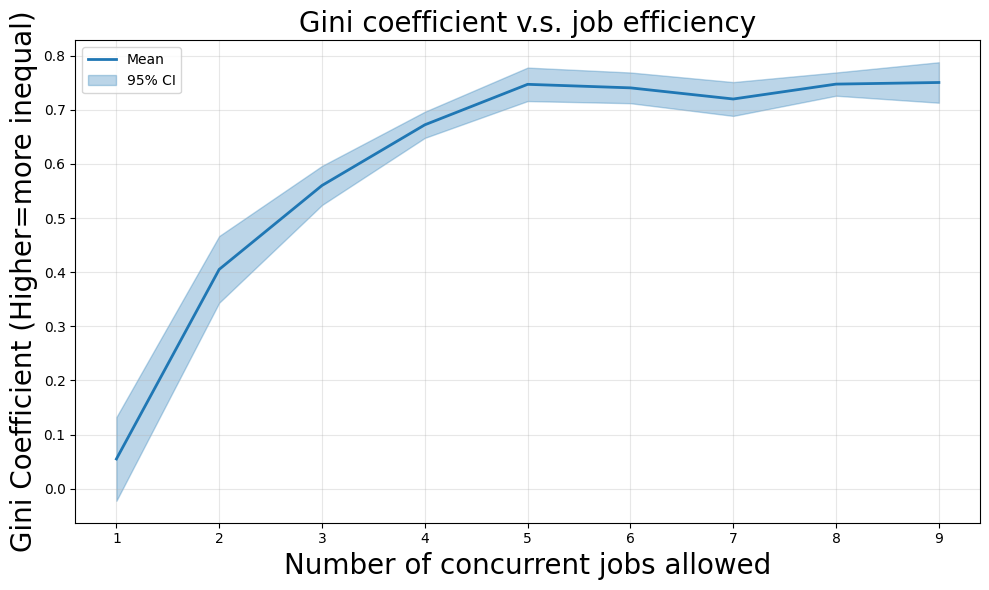

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_confidence_interval(means, stds, title="Time Series with 95% Confidence Interval"):
    """
    Plot mean with 95% confidence interval using fill_between.
    
    Args:
        means: array of mean values (length 20)
        stds: array of standard deviation values (length 20)
    """
    time_steps = np.arange(len(means))
    
    # Calculate 95% confidence interval (1.96 * std for normal distribution)
    ci_multiplier = 1.96
    upper_bound = means + ci_multiplier * stds
    lower_bound = means - ci_multiplier * stds
    
    plt.figure(figsize=(10, 6))
    
    # Plot the mean line
    plt.plot(time_steps, means, '-', linewidth=2, label='Mean')
    
    # Fill the confidence interval
    plt.fill_between(time_steps, lower_bound, upper_bound, 
                     alpha=0.3, color='tab:blue', label='95% CI')
    
    plt.xlabel('Number of concurrent jobs allowed', fontsize=20)
    plt.ylabel('Gini Coefficient (Higher=more inequal)', fontsize=20)
    plt.title(title, fontsize=20)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

all_g = np.array(all_g)
plot_confidence_interval(all_g[:, 0], all_g[:, 1], title="Gini coefficient v.s. Job efficiency")

In [205]:
market_limit = 5

task_ids = [f"task_{i}" for i in range(10)]
tasks = [ProxyTask(t, noise=0.1) for t in task_ids]

jobs = [Job(id=f"{task_id}_{i}", task_id=task_id, job_p=0.9, base_reward=7 + i) for task_id in task_ids for i in range(5)]

agents = [PolicyAgent(agent_id=f"pol_{i}", jobs=jobs, model=None, verbose=False) for i in range(50)]
for agent in agents:
    agent.set_policy(train_p=0.2, underbid_factor=0.95)

# agents[0].set_policy(task_preferences=['task_a', 'task_b', 'task_c', 'task_d'], train_p=0)
# agents[1].set_policy(task_preferences=['task_c', 'task_b', 'task_a', 'task_d'])
# agents[2].set_policy(task_preferences=['task_b', 'task_c', 'task_a', 'task_d'])
# agents[3].set_policy(task_preferences=['task_b', 'task_c', 'task_a', 'task_d'], train_t=10)

market = LabourMarket(jobs=jobs, agent_pref_limit=50, market_pref_limit=50, market_limit=market_limit, tasks=tasks, agents=agents, skill_phi=0.1, rep_window=50, rep_lambda=0.5, rep_sensitivity=2, gumbel_t=0.0)
for _ in trange(100):
    for agent in agents:
        agent.set_policy(train_p=0.2, underbid_factor=np.clip((agent.underbid_factor * 0.99 + np.random.normal(0, 0.05)), 0, 1))
    market.simulate_timestep()

2025-09-09 05:07:13.903 | INFO     | ssa.market:__init__:118 - Set up LabourMarket with 50 agents and 50 jobs over 10 tasks. Initializing...
100%|██████████| 100/100 [00:06<00:00, 14.41it/s]


In [206]:
exp_log = market.export()

In [227]:
# agent bids interpolate
from scipy import interpolate
all_lines = []

for i in range(50):
    c = np.array(exp_log.agent_bids['task_1_2'][i])
    linear_interp = interpolate.interp1d(c[:, 0], c[:, 1], kind='linear')
    all_lines.append(linear_interp(np.arange(5, 95)))


Text(0.5, 1.0, 'Agent bid as % of client budget over time')

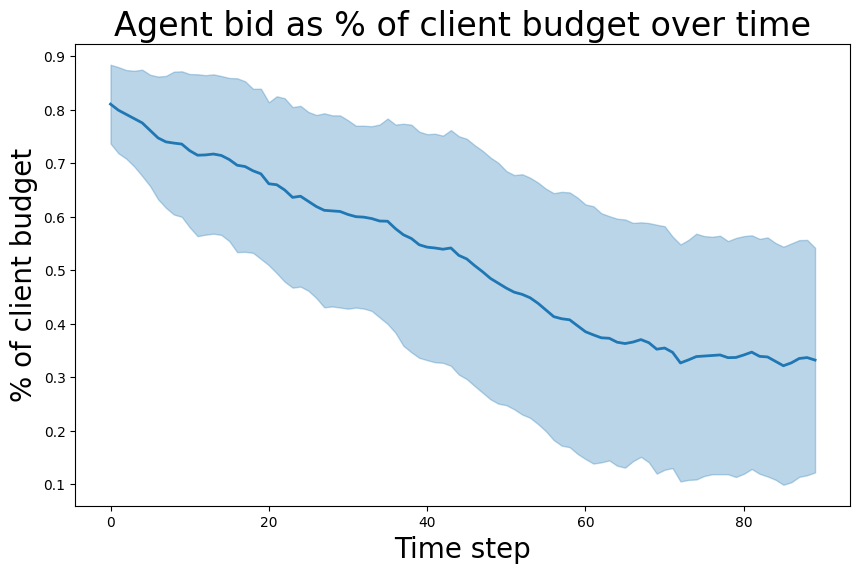

In [238]:
l = np.array(all_lines)

means = l.mean(axis=0) / 10
stds = l.std(axis=0) / 10
time_steps = np.arange(len(means))
ci_multiplier = 1
upper_bound = means + ci_multiplier * stds
lower_bound = means - ci_multiplier * stds

plt.figure(figsize=(10, 6))

# Plot the mean line
plt.plot(time_steps, means, '-', linewidth=2, label='Mean')

# Fill the confidence interval
plt.fill_between(time_steps, lower_bound, upper_bound, 
                    alpha=0.3, color='tab:blue', label='95% CI')

plt.xlabel("Time step", fontsize=20)
plt.ylabel("% of client budget", fontsize=20)
plt.title("Agent bid as % of client budget over time", fontsize=24)

In [218]:
for i in range(50):
    c = np.array(exp_log.agent_bids['task_1_2']).mean(axis=-1)
    plt.plot(c[:, 0], c[:, 1])

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (50,) + inhomogeneous part.

2025-09-10 12:52:09.538 | INFO     | ssa.market:__init__:118 - Set up LabourMarket with 7 agents and 16 jobs over 4 tasks. Initializing...
  0%|          | 0/50 [00:00<?, ?it/s]2025-09-10 12:52:09.550 | INFO     | ssa.agents.llm:get_agent_action:161 - === ROUND 1 ===

RECENT MARKET ACTIVITY (Last 10 rounds):
This is Round 1. No history recorded yet.

PREVIOUS REASONING
(First Turn - No reasoning trace yet)

YOUR RECENT ACTIONS:

>> REPUTATION - task_a: 0.25 | task_c: 0.26 | task_b: 0.25 | task_d: 0.27

THIS ROUND'S LISTINGS (task_id: job_id@client_budget, grouped by task types):
task_a: task_a_0@7.0, task_a_1@8.0, task_a_2@9.0, task_a_3@10.0
task_b: task_b_0@7.0, task_b_1@8.0, task_b_2@9.0, task_b_3@10.0
task_c: task_c_0@7.0, task_c_1@8.0, task_c_2@9.0, task_c_3@10.0
task_d: task_d_0@7.0, task_d_1@8.0, task_d_2@9.0, task_d_3@10.0

2025-09-10 12:52:09.556 | INFO     | ssa.agents.llm:get_agent_action:161 - === ROUND 2 ===

RECENT MARKET ACTIVITY (Last 10 rounds):
R1: task_a_0@7.0→ssa_0(0

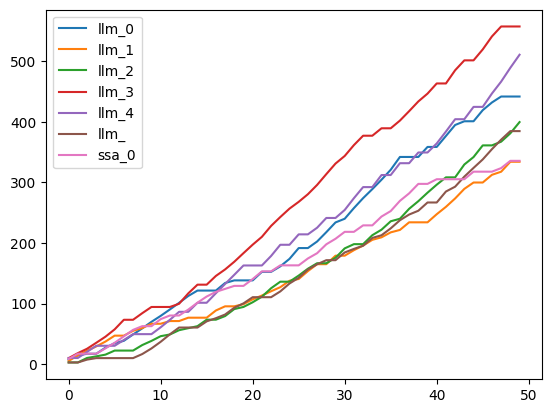

In [15]:
# %%
from ssa.market import LabourMarket, ExperimentLog, Job
from ssa.agents import StaticAgent, LLMAgent, OracleAgent, ImproveAgent
from ssa.agents.ssa import LLMSSA
from ssa.agents.policy import PolicyAgent
from ssa.tasks.cipher import CipherAgent, CipherTask
from ssa.tasks import ProxyAgent, ProxyTask
from ssa.utils import init_azure_model, init_openrouter_chat_model
from tqdm import trange
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(13123)
# model = init_azure_model()

task_ids = ["task_a", "task_b", "task_c", "task_d"]
tasks = [ProxyTask(t, noise=0.1) for t in task_ids]

jobs = [Job(id=f"{task_id}_{i}", task_id=task_id, base_reward=7 + i) for task_id in task_ids for i in range(4)]

# agents = [PolicyAgent(agent_id=f"pol_{i}", jobs=jobs, model=None, verbose=False) for i in range(4)]
# for agent in agents:
#     agent.set_policy(underbid_factor=0.9)

# agents[0].set_policy(task_preferences=['task_a', 'task_b', 'task_c', 'task_d'], train_p=0)
# # agents[1].set_policy(task_preferences=['task_c', 'task_b', 'task_a', 'task_d'])
# # agents[2].set_policy(task_preferences=['task_b', 'task_c', 'task_a', 'task_d'])
# agents[3].set_policy(task_preferences=['task_b', 'task_c', 'task_a', 'task_d'], train_t=10)

agents = []
# model = init_openrouter_chat_model(model_name='openai/gpt-oss-120b', temperature=0.5)
model = None
agents.append(LLMAgent(agent_id=f"llm_0", jobs=jobs, model=model, verbose=False))
agents.append(LLMAgent(agent_id=f"llm_1", jobs=jobs, model=model, verbose=False))
agents.append(LLMAgent(agent_id=f"llm_2", jobs=jobs, model=model, verbose=False))
agents.append(LLMAgent(agent_id=f"llm_3", jobs=jobs, model=model, verbose=False))
agents.append(LLMAgent(agent_id=f"llm_4", jobs=jobs, model=model, verbose=False))
agents.append(LLMAgent(agent_id=f"llm_", jobs=jobs, model=model, verbose=False))
agents.append(LLMSSA(agent_id=f"ssa_0", jobs=jobs, model=model, verbose=True))


market = LabourMarket(jobs=jobs, market_limit=3, tasks=tasks, agents=agents, skill_phi=0.1, rep_window=20, rep_lambda=0.5, rep_sensitivity=2, gumbel_t=0.0)
for _ in trange(50):
    market.simulate_timestep()

hx = market.get_job_performance(task_id='task_a', filter_initial=True)

exp_log = market.export('logs/ssa_test_4.log')

rew = np.cumsum(exp_log.agent_reward_history, axis=1)
plt.plot(rew.T, label=exp_log.agent_ids)
plt.legend()


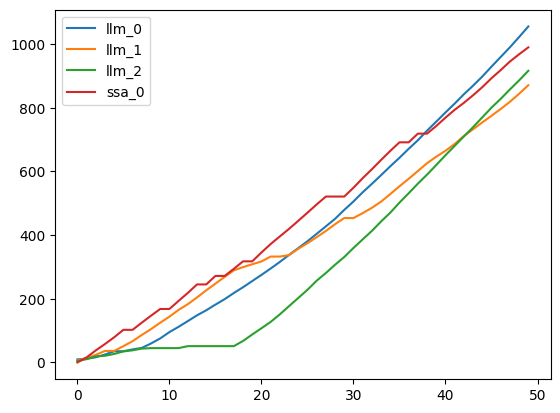

In [4]:
exp_log = market.export('logs/ssa_test_2.log')

rew = np.cumsum(exp_log.agent_reward_history, axis=1)
plt.plot(rew.T, label=exp_log.agent_ids)
plt.legend()


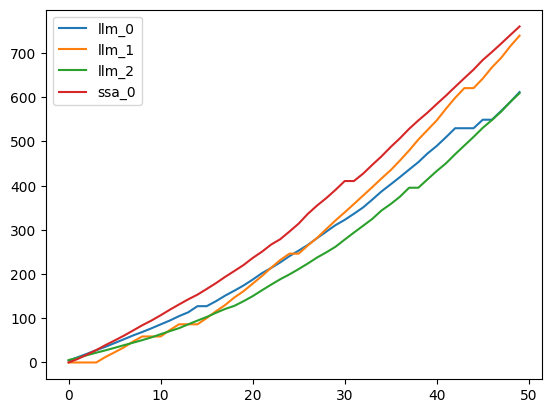

In [16]:

exp_log = market.export('logs/ssa_test_1.log')

rew = np.cumsum(exp_log.agent_reward_history, axis=1)
plt.plot(rew.T, label=exp_log.agent_ids)
plt.legend()

In [3]:
for agent in market.agents:
    agent.token_usage = [t for t in agent.token_usage if t]


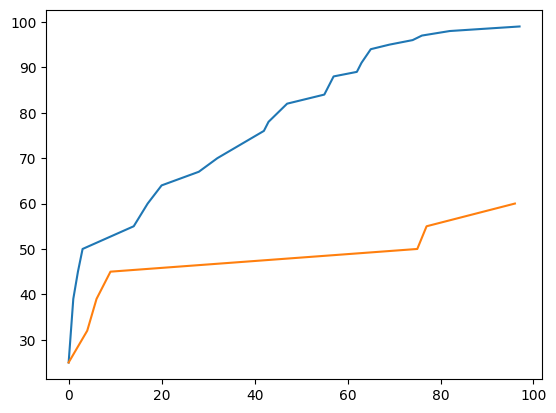

In [21]:
x, y = exp_log.agents[-1].skill_history['task_a']
plt.plot(x, y)
x, y = exp_log.agents[0].skill_history['task_a']
plt.plot(x, y)

In [ ]:
# exp_log = market.export('logs/llm_baseline_1.log')

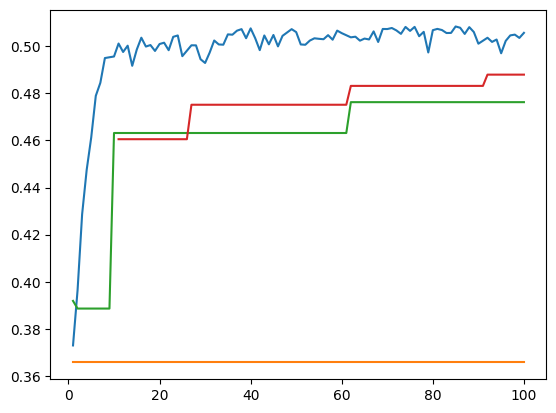

In [2]:
for agent_trace in exp_log.agent_scores['task_a_1']:
    agent_trace = np.array(agent_trace)
    plt.plot(agent_trace[:, 0], agent_trace[:, 1])

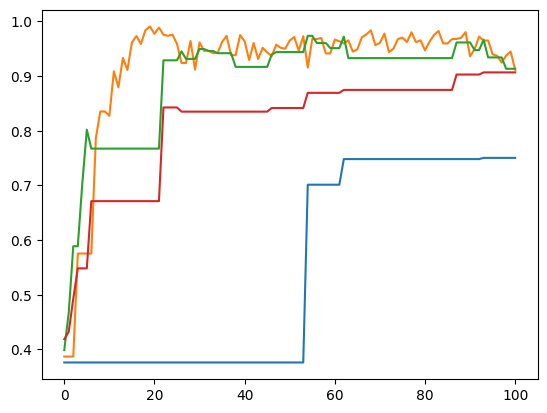

In [ ]:
plt.plot(np.array(exp_log.agent_reputation['task_c']).T)

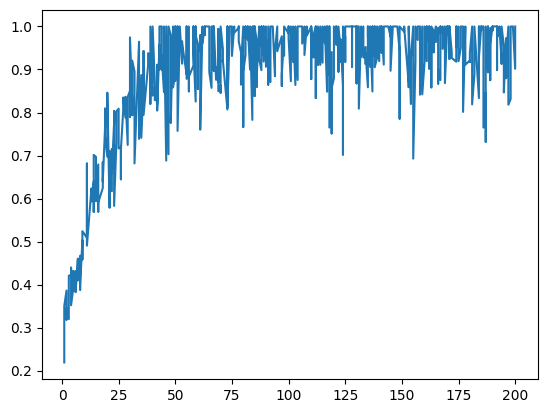

In [42]:
hx = market.get_job_performance(task_id='task_a', agent_idx=0, filter_initial=True)

import matplotlib.pyplot as plt

plt.plot([p.round for p in hx], [p.performance for p in hx], label='performance')

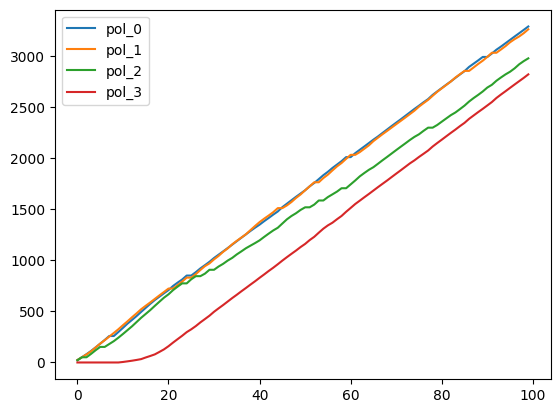

In [4]:
import matplotlib.pyplot as plt

# plt.plot([p.round for p in hx], [p.performance for p in hx])
# plt.plot([p.round for p in hx], [p.reputation for p in hx])

exp_log = market.export()
rew = np.cumsum(exp_log.agent_reward_history, axis=1)
plt.plot(rew.T, label=exp_log.agent_ids)
plt.legend()


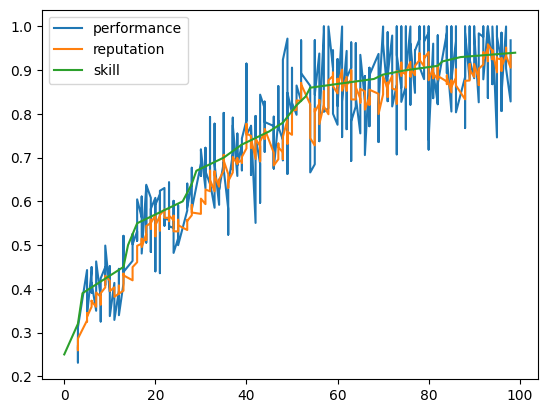

In [36]:
task_id = 'task_c'
hx = market.get_job_performance(task_id=task_id, agent_idx=0, filter_initial=True)

import matplotlib.pyplot as plt

plt.plot([p.round for p in hx], [p.performance for p in hx], label='performance')
plt.plot([p.round for p in hx], [p.reputation for p in hx], label='reputation')
X, y = market.agents[0].get_skill_history(task_id)
plt.plot(X, np.array(y)/100, label='skill')
plt.legend()

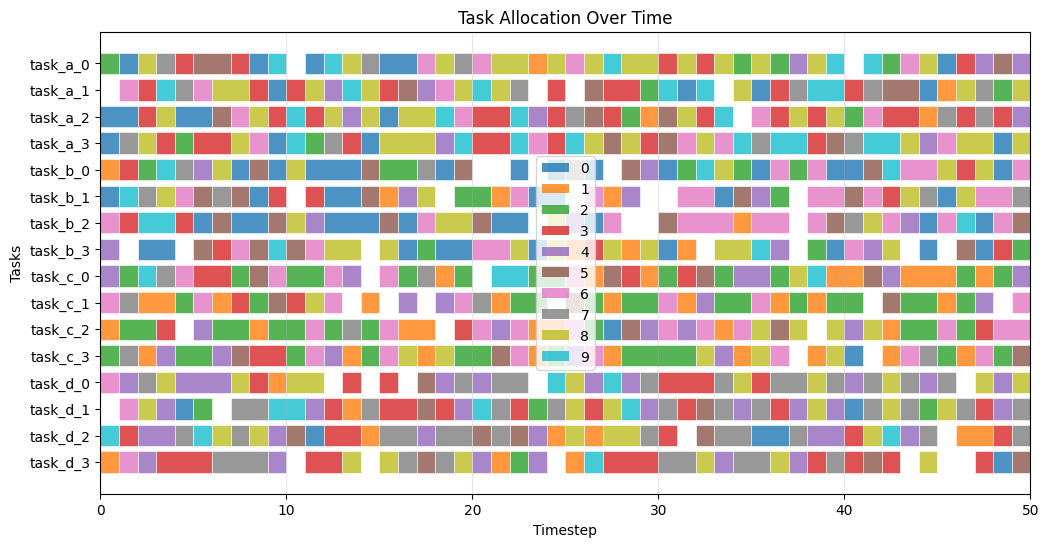

In [2]:
from ssa.plotting import plot_allocation
allocations = [history.matched_jobs for history in exp_log.history]

fig, ax = plt.subplots(figsize=(12, 6))
ax = plot_allocation(ax, allocation=allocations)